In [23]:
import numpy as np
# import sympy as sp
from plotly import express as px
from matplotlib import pyplot as plt
import pandas as pd
import scipy as scp


#IGUAL PARA TODOS LOS EXPERIMENTOS AL MENOS DEL MIERCOLES PASADO QSY NO CREO QUE NADIE VAYA A LEER ESTO HOLA CUCHU

# V1=pd.read_csv('V_1.csv')
# V2=pd.read_csv('V_2.csv')
# V3=pd.read_csv('V_3.csv')
V4=pd.read_csv('V_4.csv')
V5a=pd.read_csv('V_5_ascensor.csv')
#V5o=pd.read_csv('V_5_octogono.csv')


In [24]:
Vtot=pd.concat([V4,V5a],ignore_index=True)
Vtot=Vtot.sort_values(by=['d'])
Vtot
d=Vtot['d']
V=Vtot['V']
d1=V4['d']
V1=V4['V']
d2=V5a['d']
V2=V5a['V']



In [25]:
#########FUNCIONES

def funkfit (x,a,b,c,d):
    """ a*np.sin(2 pi* b * x + c )+d """
    return a*np.sin(2*np.pi*b*x+c)+d

def B_short(x,n,a,log=False):
    if log:
        return np.exp(a)*x**n
    else:    
        return a*x**n

def lock_in(datos,f):
    x,y =datos['Second'],datos['Volt.1']
    
    # print(x,'\n',y)
    dx=x.iloc[-1]-x.iloc[0]
    
    y_cos= np.cos(2*np.pi*f*x)* y
    y_sin= np.sin(2*np.pi*f*x)* y

    U_cos=1/dx*np.trapz(y_cos,x=x)
    U_sin=1/dx*np.trapz(y_sin,x=x)

    
    # plt.figure()
    # plt.plot(y_cos)
    r=((2*U_cos)**2+(2*U_sin)**2)**.5
    phi=np.arctan2(U_sin,U_cos)

    return r,phi

def plotplot(d,V):
    plt.plot(d,V,'o--')

    plt.title('Voltaje en función de la distancia',fontsize=30)
    plt.legend(['Voltaje'],fontsize=18)

    plt.xlabel('Distancia [m]',fontsize=18)
    plt.ylabel('Voltaje [V]',fontsize=18)


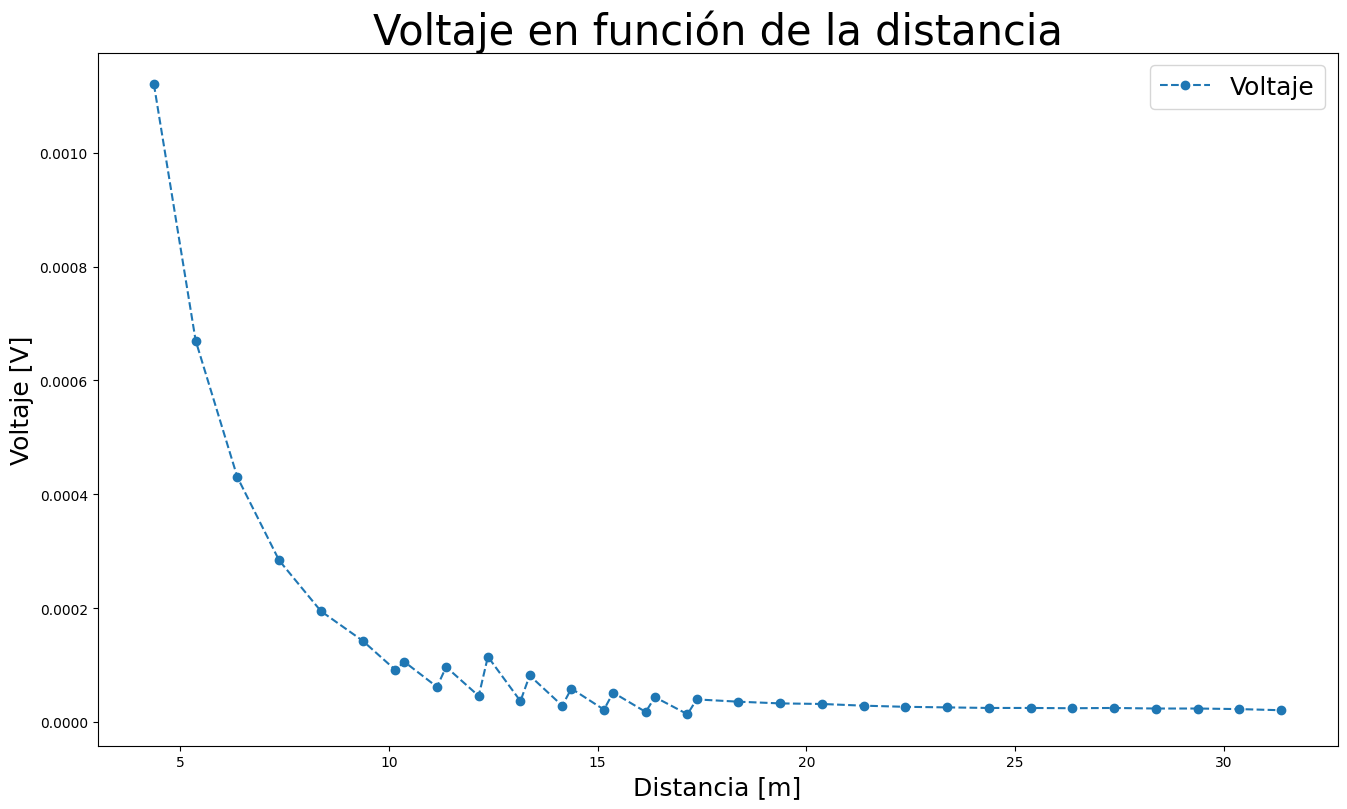

In [26]:
plt.figure(figsize=(16,9))
plotplot(d,V)

In [27]:
otaduy=np.average(np.array(V1[6])/(V2[0]))



In [28]:
len(V2)

8

In [29]:
V1.tail(), V2.tail()

(23    0.000025
 24    0.000024
 25    0.000024
 26    0.000023
 27    0.000021
 Name: V, dtype: float64,
 3    0.000037
 4    0.000029
 5    0.000022
 6    0.000018
 7    0.000014
 Name: V, dtype: float64)

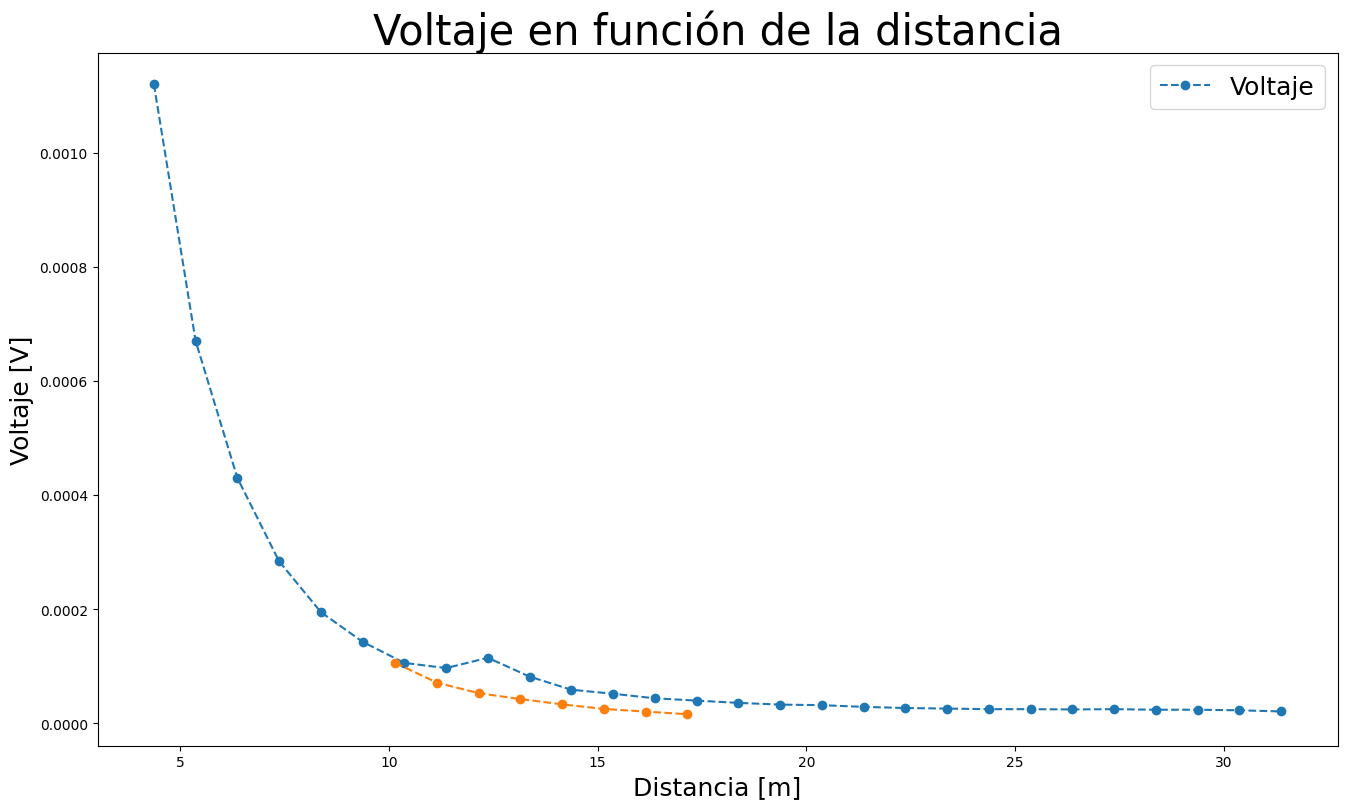

In [30]:
plt.figure(figsize=(16,9))
plotplot(d1,V1)
plotplot(d2,V2*otaduy)


In [31]:
otaduy

1.1521739130434783

Text(0, 0.5, 'Voltaje [V]')

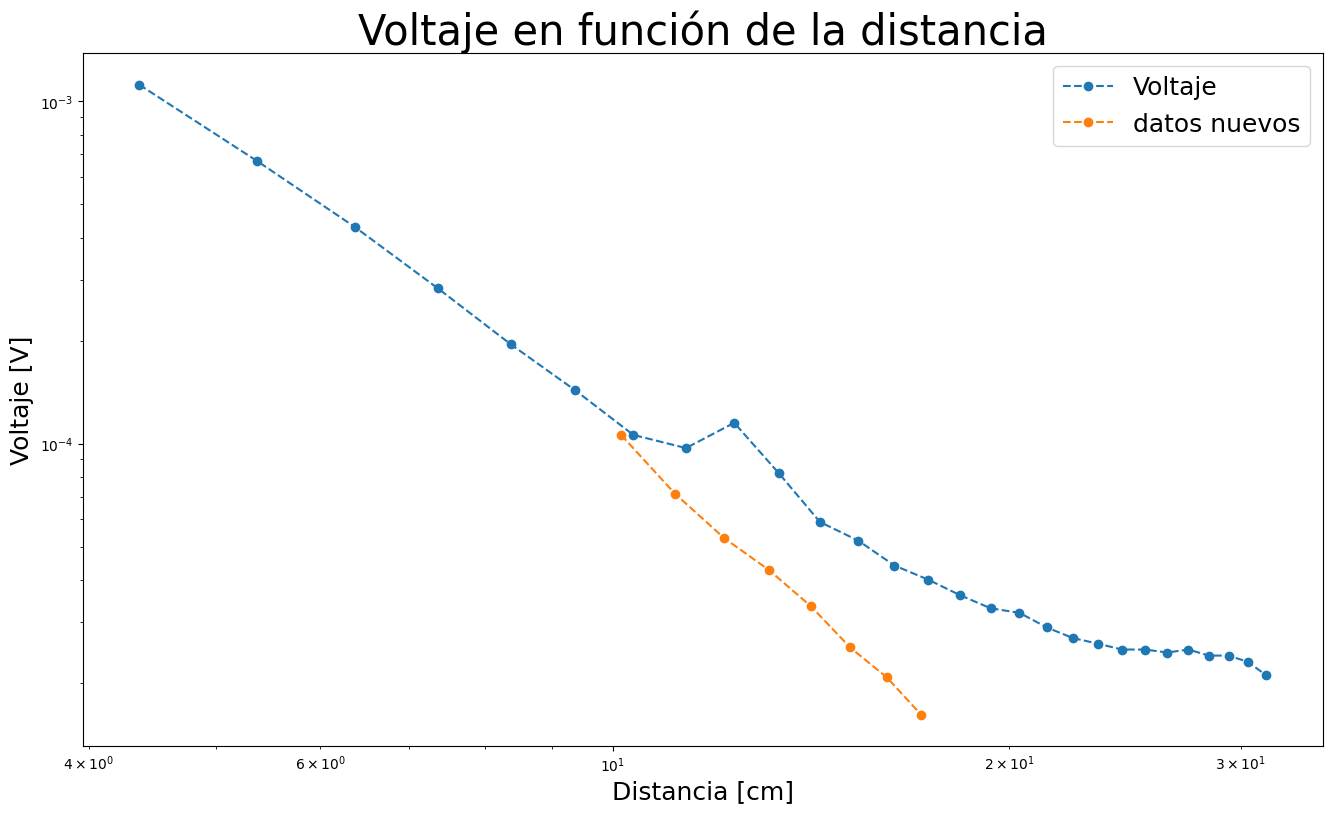

In [32]:
plt.figure(figsize=(16,9))
# plt.loglog(d,V,'o--')
plt.loglog(d1,V1,'o--')
plt.loglog(d2,V2*otaduy,'o--')
plt.title('Voltaje en función de la distancia',fontsize=30)
plt.legend(['Voltaje','datos nuevos'],fontsize=18)

plt.xlabel('Distancia [cm]',fontsize=18)
plt.ylabel('Voltaje [V]',fontsize=18)

In [21]:
cutinf=0
cuthigh=len(V)

d_input=pd.concat([d1[:6],d2])
V_input=pd.concat([V1[:6],V2*otaduy])
#n=8
# dtest=list(d[:n])+list(d[n+1:])
# vtest=list(V[:n])+list(V[n+1:])
P=np.polyfit(np.log(d_input[cutinf:cuthigh]),np.log(V_input[cutinf:cuthigh]),1)
# P=np.polyfit(np.log(dtest),np.log(vtest),1)

#P=np.polyfit(np.log(distd2[1:-1]),np.log(V2[1:-1]),1)
P

array([-3.15097041, -1.95658148])

In [ ]:
abs(3-3.29708839)/3

0.09902946333333329

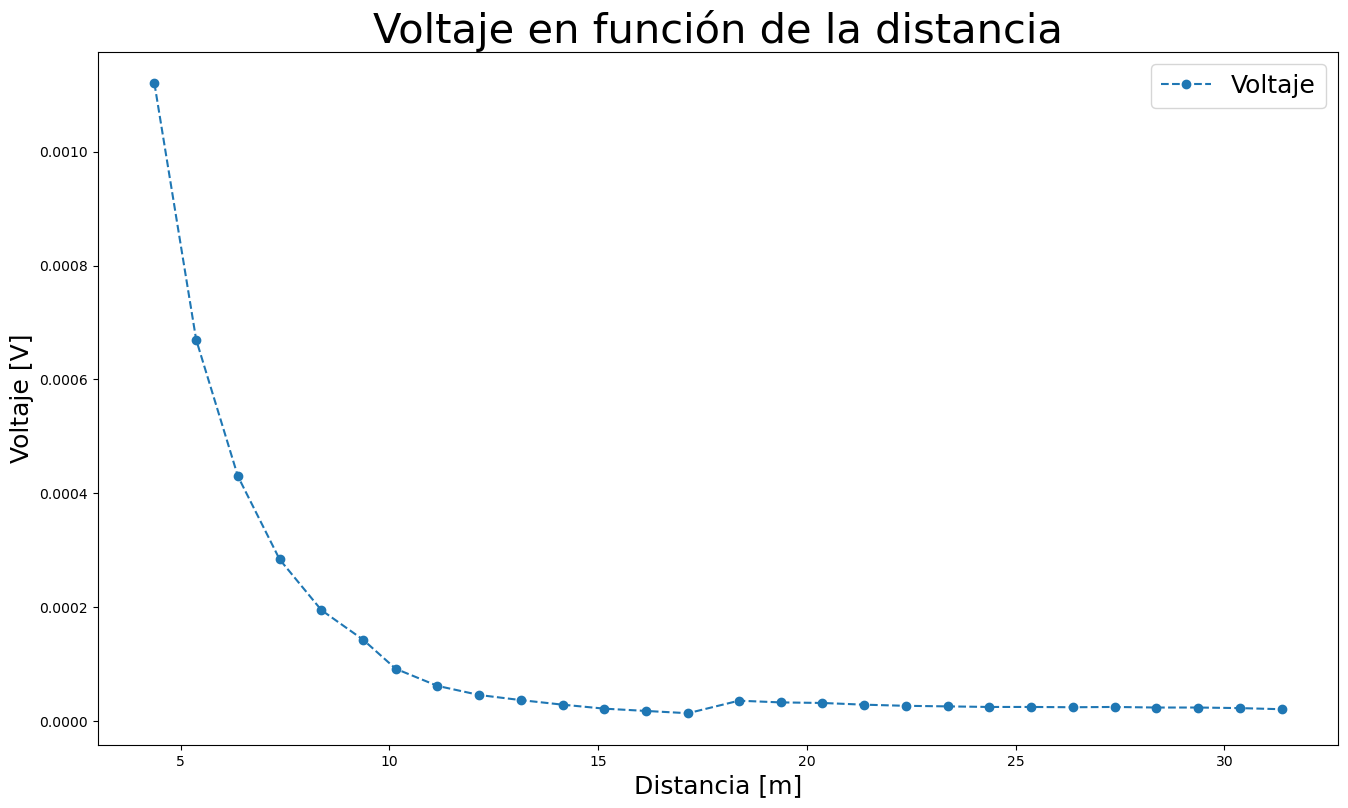

In [ ]:
plt.figure(figsize=(16,9))
plotplot(d_input,V_input)

Text(0, 0.5, 'Voltaje [V]')

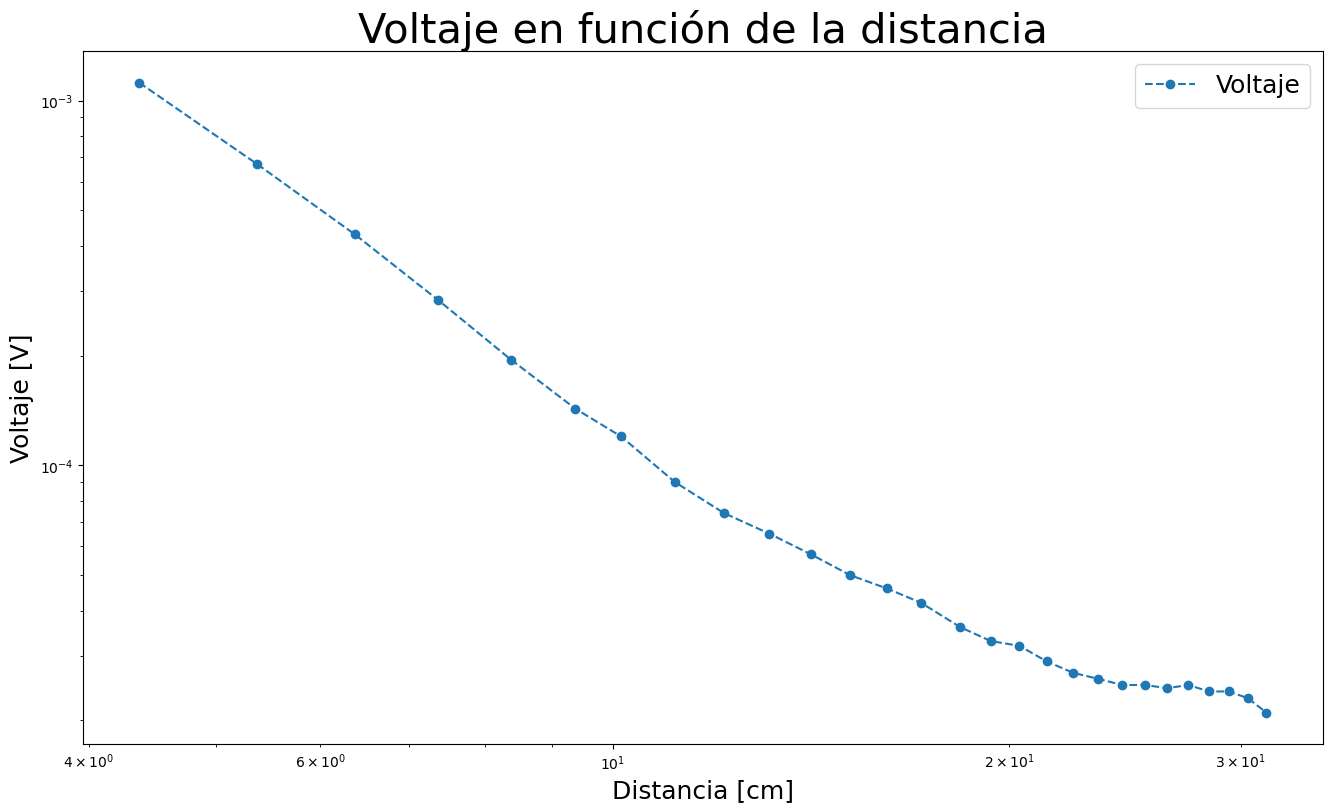

In [ ]:
plt.figure(figsize=(16,9))
plt.loglog(d_input,V_input,'o--')
# plt.loglog(d,B_short(d,*P,log=True),'o--')
plt.title('Voltaje en función de la distancia',fontsize=30)
plt.legend(['Voltaje','Ajuste lineal'],fontsize=18)

plt.xlabel('Distancia [cm]',fontsize=18)
plt.ylabel('Voltaje [V]',fontsize=18)